In [1]:
import os
import sys
import random

import torch
torch.set_float32_matmul_precision('medium')
import torch.nn as nn
import torch.optim as optim

import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.loggers import TensorBoardLogger, CSVLogger

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from PIL import Image
from torchvision import models, transforms
import torchvision.transforms as T

from torch.utils.data import Dataset, DataLoader, TensorDataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, r2_score, mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score, balanced_accuracy_score, top_k_accuracy_score

import tensorboard

sys.path.append('/home/jko/ice3d-ml-paper')
from models.mlp_regression import MLPRegression
from models.mlp_classification import MLPClassification
from models.resnet18_regression import ResNet18Regression
from models.resnet18_classification import ResNet18Classification
from models.cnn_regression import VanillaCNNRegression
from models.cnn_classification import VanillaCNNClassification

os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
from data.tabular_datamodule import TabularDataModule
from data.tabular_dataset import TabularDataset
from data.single_view_datamodule import SingleViewDataModule
from data.single_view_dataset import SingleViewDataset
from data.stereo_view_datamodule import StereoViewDataModule
from data.stereo_view_dataset import StereoViewDataset
import json
from torchvision.models import ResNet18_Weights

import pickle
import joblib
from sklearn.preprocessing import StandardScaler

import math
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LogNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext

# Setup

In [2]:
# imagery
second_view = '2ds'
hdf_dir = '/home/jko/synth-ros-data/imgs-ml-ready/shuffled_small'
hdf_file1 = 'default_shuffled_small.h5'
hdf_file2 = f'{second_view}_shuffled_small.h5'
hdf_path1 = os.path.join(hdf_dir, hdf_file1)
hdf_path2 = os.path.join(hdf_dir, hdf_file2)
# tabular
tab_dir = '/home/jko/synth-ros-data/tabular-data-v2/shuffled_small'
tab_file = 'ros-tabular-data-shuffled-default-subset-700000.parquet'
tab_path = os.path.join(tab_dir, tab_file)
tab_stereo_2ds_file = 'ros-tabular-data-stereo-default-2ds-shuffled-subset-700000.parquet'
tab_stereo_2ds_path = os.path.join(tab_dir, tab_stereo_2ds_file)
tab_stereo_phips_file = 'ros-tabular-data-stereo-default-phips-shuffled-subset-700000.parquet'
tab_stereo_phips_path = os.path.join(tab_dir, tab_stereo_phips_file)
# Load the class mapping from a JSON file
class_mapping_file = '/home/jko/ice3d/data/class_to_idx.json'
# where to save plots
savedir = './figs/test-results-v2'
os.makedirs(savedir, exist_ok=True)
# Load class mapping from JSON file
with open(class_mapping_file, 'r') as f:
    class_to_idx = json.load(f)
num_classes = len(class_to_idx)  # Number of unique classes in n_arms

# set up data
features_default = ['aspect_ratio', 'aspect_ratio_elip', 
'extreme_pts', 'contour_area', 'contour_perimeter', 
'area_ratio', 'complexity', 'circularity']
features_stereo = ['aspect_ratio_1', 'aspect_ratio_elip_1', 
'extreme_pts_1', 'contour_area_1', 'contour_perimeter_1', 
'area_ratio_1', 'complexity_1', 'circularity_1',
'aspect_ratio_2', 'aspect_ratio_elip_2', 'extreme_pts_2', 
'contour_area_2', 'contour_perimeter_2', 'area_ratio_2', 
'complexity_2', 'circularity_2']
features_reg_reduced=['area_ratio', 'contour_area', 'contour_perimeter', 'circularity'] # reduced set features for regression
features_cls_reduced=['area_ratio', 'complexity', 'contour_perimeter', 'contour_area'] # reduced set features for classification
targets_reg = ['rho_eff', 'sa_eff']
targets_cls = ['n_arms']
batch_size = 128
n_rand = 666
num_workers = 16
def log_transform(x):
    return torch.log(x)
split = [0.7, 0.15, 0.15]
n_data = 700_000
assert abs(sum(split) - 1.0) < 1e-8, "Split does not sum to 1"
n_train = int(split[0] * n_data)
n_val = int(split[1] * n_data)
n_test = n_data - n_train - n_val  # ensures all data is used
train_idx = list(range(0, n_train))
val_idx = list(range(n_train, n_train + n_val))
test_idx = list(range(n_train + n_val, n_data))

# set colors
cmap_reg = 'magma'
cmap_cls = 'Blues'

# global plot parameters 
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['font.size'] = 14

# define transforms
def get_transforms(data_type, input_channels, task_type):
    transforms = {}
    # Define transforms based on data_type
    if data_type in ['single_view_h5', 'stereo_view_h5']:
        train_transform = T.Compose([
                T.RandomHorizontalFlip(),
                T.RandomVerticalFlip(),
                T.Normalize(mean=[0.5] * input_channels, std=[1.0] * input_channels)
            ])
        val_transform = T.Compose([
                T.Normalize(mean=[0.5] * input_channels, std=[1.0] * input_channels)
            ])
        transforms['train'] = train_transform
        transforms['val'] = val_transform
        transforms['test'] = val_transform
        # define target transform
        if task_type == 'classification':
            target_transform = None
        else:
            def log_transform(x):
                return torch.log(x)
            target_transform = log_transform
        transforms['train_target'] = target_transform
        transforms['val_target'] = target_transform
        transforms['test_target'] = target_transform    
        return transforms
    elif data_type == 'tabular':
        # define target transform
        if task_type == 'classification':
            target_transform = None
        else:
            def log_transform(x):
                return torch.log(x)
            target_transform = log_transform
        transforms['target'] = target_transform
        return transforms
    else:
        return None
data_type = 'stereo_view_h5'
input_channels = 2
task_type = 'classification'
transforms = get_transforms(data_type, input_channels, task_type)

# create dataframe to save metrics for all models
metrics_reg = {}
metrics_cls = {}

In [3]:
# define scatter plot limits
scatter_limits = {}
scatter_limits['rho'] = [-0.05, 0.3]
scatter_limits['sa'] = [0, 1.0]

# cbar limits 
cbar_limits = {}
cbar_limits['rho'] = [1e0, 2e4]
cbar_limits['sa'] = [1e0, 2e3]
cbar_limits['n_arms'] = [0, 1]

# function to nicely space of tick marks
def nice_step(lims, target=5):
    lo, hi = lims
    span = hi - lo
    raw = span / target if span > 0 else 1.0
    exp = math.floor(math.log10(raw))
    frac = raw / (10**exp)
    for m in (1, 2, 2.5, 5, 10):
        if frac <= m:
            return m * (10**exp)
    return 10 * (10**exp)

# Regression

In [4]:
data_type = 'tabular'
input_channels = 2
task_type = 'regression'
transforms = get_transforms(data_type, input_channels, task_type)
dm = TabularDataModule(
    data_file=tab_path,
    feature_names=features_reg_reduced,
    target_names=targets_reg,
    batch_size=batch_size,
    subset_size=1.0,
    subset_seed=n_rand,
    num_workers=num_workers,
    task_type='regression',
    class_to_idx=None,
    target_transform=transforms['target'],
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)
dm.setup()

In [5]:
model_ckpt = '/home/jko/ice3d-ml-paper/lightning_logs/mlp-reg-csv/version_1/checkpoints/lin-reg-reduced-features-epoch=36-val_loss=0.0150.ckpt'
model = MLPRegression.load_from_checkpoint(
    checkpoint_path=model_ckpt,
    input_size=4, 
    output_size=2, 
    learning_rate=1e-3, 
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

MLPRegression(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)

In [6]:
loader = dm.test_dataloader()
all_preds = []
all_targets = []
# n_batches=10
# Run inference on the test data and print progress
print_frq = 100
with torch.no_grad():
    total_batches = len(loader)
    for i, batch in enumerate(loader):
        # if i >= n_batches:  # Stop after 20 batches
        #     break
        if i % print_frq == 0:
            print(f"Processing batch {i + 1} out of {total_batches}...")
        features, targets = batch
        features = features.to(device)
        targets = targets.to(device)
        preds = model(features)
        # Apply inverse log transform to both predictions and targets
        preds = torch.exp(preds)  # Inverse of log
        targets = torch.exp(targets)  # Inverse of log
        all_preds.append(preds.cpu().numpy())
        all_targets.append(targets.cpu().numpy())

# Concatenate all predictions and targets
all_preds = np.concatenate(all_preds, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

Processing batch 1 out of 821...
Processing batch 101 out of 821...
Processing batch 201 out of 821...
Processing batch 301 out of 821...
Processing batch 401 out of 821...
Processing batch 501 out of 821...
Processing batch 601 out of 821...
Processing batch 701 out of 821...
Processing batch 801 out of 821...


In [7]:
# compute metrics and save
rho_true = all_targets[:, 0]
rho_pred = all_preds[:, 0]
sa_true = all_targets[:, 1]
sa_pred = all_preds[:, 1]
# Compute RMSE
rmse_rho = float(np.sqrt(mean_squared_error(rho_true, rho_pred)))
print("RMSE for rho_eff:", rmse_rho)
rmse_sa = float(np.sqrt(mean_squared_error(sa_true, sa_pred)))
print("RMSE for sa_eff:", rmse_sa)
# Compute MAE
mae_rho = float(np.sqrt(mean_absolute_error(rho_true, rho_pred)))
print("MAE for rho_eff:", mae_rho)
mae_sa = float(np.sqrt(mean_absolute_error(sa_true, sa_pred)))
print("MAE for sa_eff:", mae_sa)

# get score
r2_rho = r2_score(rho_true, rho_pred)
r2_sa = r2_score(sa_true, sa_pred)
print(f'R2 for effective density = {r2_rho}')
print(f'R2 for effective surface area = {r2_sa}')

# save metrics 
metrics = [rmse_rho, rmse_sa, mae_rho, mae_sa, r2_rho, r2_sa]
metrics_reg['mlp_default'] = metrics

RMSE for rho_eff: 0.009712670219121408
RMSE for sa_eff: 0.04136604103295378
MAE for rho_eff: 0.08033372629140934
MAE for sa_eff: 0.17672835678917223
R2 for effective density = 0.9528413414955139
R2 for effective surface area = 0.9196727275848389


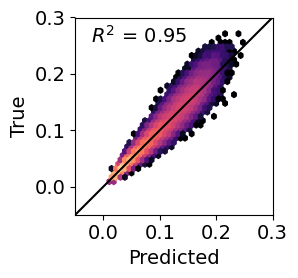

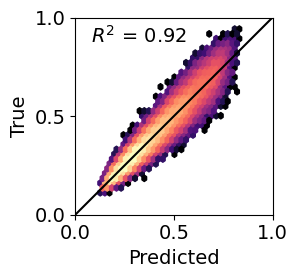

In [8]:
# Plot for rho_eff (styled)
fig1, ax1 = plt.subplots(figsize=(4, 3))
hb1 = ax1.hexbin(
    rho_pred, rho_true,
    gridsize=30, cmap=cmap_reg, mincnt=1,
    norm=LogNorm(vmin=cbar_limits['rho'][0], vmax=cbar_limits['rho'][1])
)
ax1.axline(xy1=(0, 0), slope=1, color='black')
lims_rho = scatter_limits['rho']
step_rho = nice_step(lims_rho, target=4)
ax1.set_xlim(lims_rho[0], lims_rho[1])
ax1.set_ylim(lims_rho[0], lims_rho[1])
ax1.xaxis.set_major_locator(MultipleLocator(step_rho))
ax1.yaxis.set_major_locator(MultipleLocator(step_rho))
ax1.set_aspect('equal')
ax1.set_ylabel('True')
ax1.set_xlabel('Predicted')
ax1.text(0.08, 0.87, f'$R^2$ = {r2_rho:.2f}', transform=ax1.transAxes, ha='left')
plt.tight_layout()
savepath1 = os.path.join(savedir, 'mlp_reg_reduced_default_scatter_rho.png')
plt.savefig(savepath1, dpi=300)

# Plot for sa_eff (styled)
fig2, ax2 = plt.subplots(figsize=(4, 3))
hb2 = ax2.hexbin(
    sa_pred, sa_true,
    gridsize=30, cmap=cmap_reg, mincnt=1,
    norm=LogNorm(vmin=cbar_limits['sa'][0], vmax=cbar_limits['sa'][1])
)
ax2.axline(xy1=(0, 0), slope=1, color='black')
lims_sa = scatter_limits['sa']
step_sa = nice_step(lims_sa, target=3)
ax2.set_xlim(lims_sa[0], lims_sa[1])
ax2.set_ylim(lims_sa[0], lims_sa[1])
ax2.xaxis.set_major_locator(MultipleLocator(step_sa))
ax2.yaxis.set_major_locator(MultipleLocator(step_sa))
ax2.set_aspect('equal')
ax2.set_ylabel('True')
ax2.set_xlabel('Predicted')
ax2.text(0.08, 0.87, f'$R^2$ = {r2_sa:.2f}', transform=ax2.transAxes, ha='left')
plt.tight_layout()
savepath2 = os.path.join(savedir, 'mlp_reg_reduced_default_scatter_sa.png')
plt.savefig(savepath2, dpi=300)

# Classification

In [9]:
data_type = 'tabular'
input_channels = 2
task_type = 'classification'
transforms = get_transforms(data_type, input_channels, task_type)
dm = TabularDataModule(
    data_file=tab_path,
    feature_names=features_cls_reduced,
    target_names=targets_cls,
    batch_size=batch_size,
    subset_size=1.0,
    subset_seed=n_rand,
    num_workers=num_workers,
    task_type='classification',
    class_to_idx=class_to_idx,
    target_transform=transforms['target'],
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx,
)
dm.setup()

In [10]:
model_ckpt = '/home/jko/ice3d-ml-paper/lightning_logs/mlp-cls-csv/version_1/checkpoints/log-reg-reduced-features-epoch=35-val_loss=1.2208.ckpt'
model = MLPClassification.load_from_checkpoint(
    checkpoint_path=model_ckpt,
    input_size=4, 
    num_classes=7, 
    learning_rate=1e-3, 
)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

MLPClassification(
  (fc1): Linear(in_features=4, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=7, bias=True)
)

In [11]:
loader = dm.test_dataloader()
all_preds = []
all_probs = []
all_targets = []
print_frq = 100
# Run inference on the test data and print progress
with torch.no_grad():
    total_batches = len(loader)
    for i, batch in enumerate(loader):
        if i % print_frq == 0:
            print(f"Processing batch {i + 1} out of {total_batches}...")
        features, targets = batch
        features = features.to(device)
        targets = targets.to(device)
        preds = model(features)
        # Get probabilities using softmax
        probs = torch.softmax(preds, dim=1)
        all_preds.append(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
# Concatenate all predictions and targets
all_preds = np.concatenate(all_preds, axis=0)
all_probs = np.concatenate(all_probs, axis=0)
all_targets = np.concatenate(all_targets, axis=0)

# Convert model outputs to predicted class indices
all_preds = np.argmax(all_preds, axis=1)

Processing batch 1 out of 821...
Processing batch 101 out of 821...
Processing batch 201 out of 821...
Processing batch 301 out of 821...
Processing batch 401 out of 821...
Processing batch 501 out of 821...
Processing batch 601 out of 821...
Processing batch 701 out of 821...
Processing batch 801 out of 821...


In [12]:
# compute and save metrics

# Assume y_true and y_test_pred are your numpy arrays
# For top-k accuracy, y_test_pred_proba should be the predicted probabilities (shape: [n_samples, n_classes])

# Binary or multiclass labels
precision = precision_score(all_targets, all_preds, average='weighted')  # or 'macro', 'micro', 'binary'
recall = recall_score(all_targets, all_preds, average='weighted')
f1 = f1_score(all_targets, all_preds, average='weighted')
balanced_acc = float(balanced_accuracy_score(all_targets, all_preds))

# For top-k accuracy (e.g., k=3)
# y_test_probs: shape (n_samples, n_classes)
top_k = float(top_k_accuracy_score(all_targets, all_probs, k=3))

# MAE (on predicted class labels; works when labels are integers)
mae = float(mean_absolute_error(all_targets, all_preds))

# collect and save metrics
metrics = [precision, recall, f1, balanced_acc, top_k, mae]
metrics_cls['mlp_default'] = metrics
print(metrics)

[0.44172928509115106, 0.447157646117656, 0.4434678114085325, 0.4471795204579724, 0.8985342996733364, 0.7031171131703507]


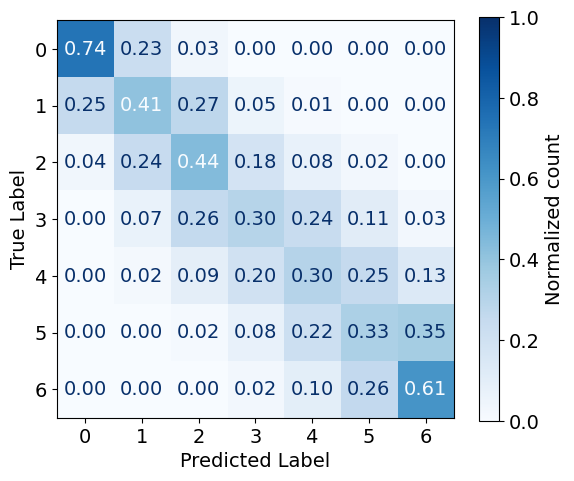

In [13]:
# Extract predictions and targets (preds = model outputs, targets = ground truth)
preds = all_preds
targets = all_targets

# Fix label order so matrix and tick labels match
labels = np.array(sorted(np.unique(np.concatenate([targets, preds]))))
cm = confusion_matrix(targets, preds, labels=labels, normalize='true')

# Integer tick labels
class_labels = [str(int(round(l))) for l in labels]

# Plot with built-in colorbar and fixed limits
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
disp.plot(
    cmap=cmap_cls,
    ax=ax,
    values_format=".2f",
    colorbar=True,
    im_kw=dict(vmin=cbar_limits['n_arms'][0], vmax=cbar_limits['n_arms'][1])
)

# Label the built-in colorbar
cax = [a for a in fig.axes if a is not ax][0]
cax.set_ylabel('Normalized count')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()

# save plot
savepath = os.path.join(savedir, 'mlp_cls_reduced_cm.png')
plt.savefig(savepath, dpi=300)
plt.show()